# 02 — Model Analysis & Visualization

Comprehensive visualizations of model performance, calibration, feature importance, and team-level insights. Every chart here is a candidate for the Streamlit dashboard.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
from nba_api.stats.static import teams as nba_static_teams

from db import engine
from src.features.matchup import load_team_games, to_matchup
from src.features.elo import add_elo, final_elos
from src.models.calibration import reliability_table, expected_calibration_error
from src.models.splits import by_season
from src.models.xgboost_model import select_features, MODELS_DIR
from src.models.evaluate import evaluate

sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
pd.set_option('display.max_columns', 60)

TEAM_LOOKUP = {t['id']: t for t in nba_static_teams.get_teams()}
def abbrev(tid): return TEAM_LOOKUP.get(int(tid), {}).get('abbreviation', str(tid))
def full_name(tid): return TEAM_LOOKUP.get(int(tid), {}).get('full_name', str(tid))

In [2]:
# Load predictions + outcomes
from sqlalchemy import text
with engine.connect() as c:
    predictions = pd.read_sql_query(text("SELECT * FROM predictions"), c)
predictions['game_date'] = pd.to_datetime(predictions['game_date'])

outcomes = to_matchup(load_team_games(engine))[['game_id', 'game_date', 'season', 'home_team_id', 'away_team_id', 'home_won']]
outcomes['game_date'] = pd.to_datetime(outcomes['game_date'])

df = predictions.merge(outcomes, on='game_id', suffixes=('', '_out'))
df['correct'] = ((df['model_prob'] >= 0.5).astype(int) == df['home_won']).astype(int)
df['home_abbrev'] = df['home_team_id'].apply(abbrev)
df['away_abbrev'] = df['away_team_id'].apply(abbrev)
df['matchup'] = df['away_abbrev'] + ' @ ' + df['home_abbrev']

print(f"Total graded predictions: {len(df)}")
print(f"Model versions: {df['model_version'].value_counts().to_dict()}")
print(f"Date range: {df['game_date'].min().date()} to {df['game_date'].max().date()}")

Total graded predictions: 2450
Model versions: {'v2': 1225, 'v1': 1225}
Date range: 2024-10-22 to 2025-04-13


## 1. Model Comparison — v1 vs v2 (tuned)

Head-to-head across all 4 metrics on the full 2024-25 out-of-sample backfill.

In [3]:
rows = []
for v in sorted(df['model_version'].unique()):
    sub = df[df['model_version'] == v]
    m = evaluate(sub['home_won'], sub['model_prob'])
    rows.append({'model': v, **m.as_dict()})
comparison = pd.DataFrame(rows).set_index('model')
comparison.style.format('{:.4f}').highlight_min(axis=0, subset=['log_loss', 'brier']).highlight_max(axis=0, subset=['accuracy', 'roc_auc'])

,n,accuracy,log_loss,brier,roc_auc
model,,,,,
v1,1225.0000,0.6718,0.6150,0.2130,0.7192
v2,1225.0000,0.6645,0.6163,0.2138,0.7166


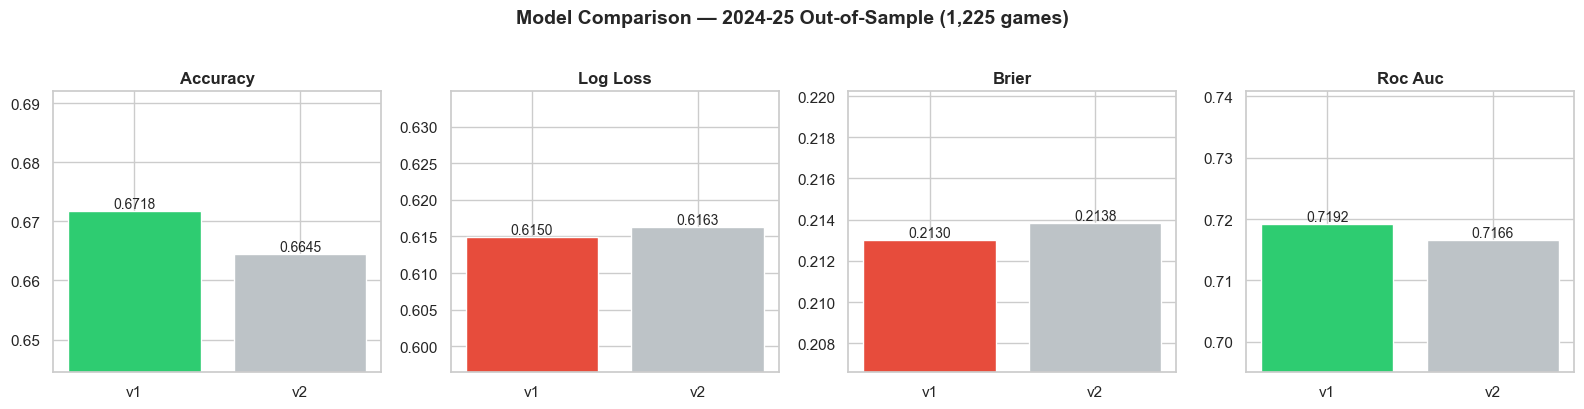

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['accuracy', 'log_loss', 'brier', 'roc_auc']
colors = ['#2ecc71', '#e74c3c', '#e74c3c', '#2ecc71']  # green=higher better, red=lower better
for ax, metric, c in zip(axes, metrics, colors):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values, color=[c if v == vals.max() else '#bdc3c7' for v in vals] if c == '#2ecc71'
                  else [c if v == vals.min() else '#bdc3c7' for v in vals])
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylim(vals.min() * 0.97, vals.max() * 1.03)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.4f}',
                ha='center', va='bottom', fontsize=10)
fig.suptitle('Model Comparison — 2024-25 Out-of-Sample (1,225 games)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

## 2. Calibration / Reliability Curves

A well-calibrated model's curve hugs the diagonal: when it says "70% home win," the home team actually wins ~70% of the time. This is the metric that matters most for betting applications.

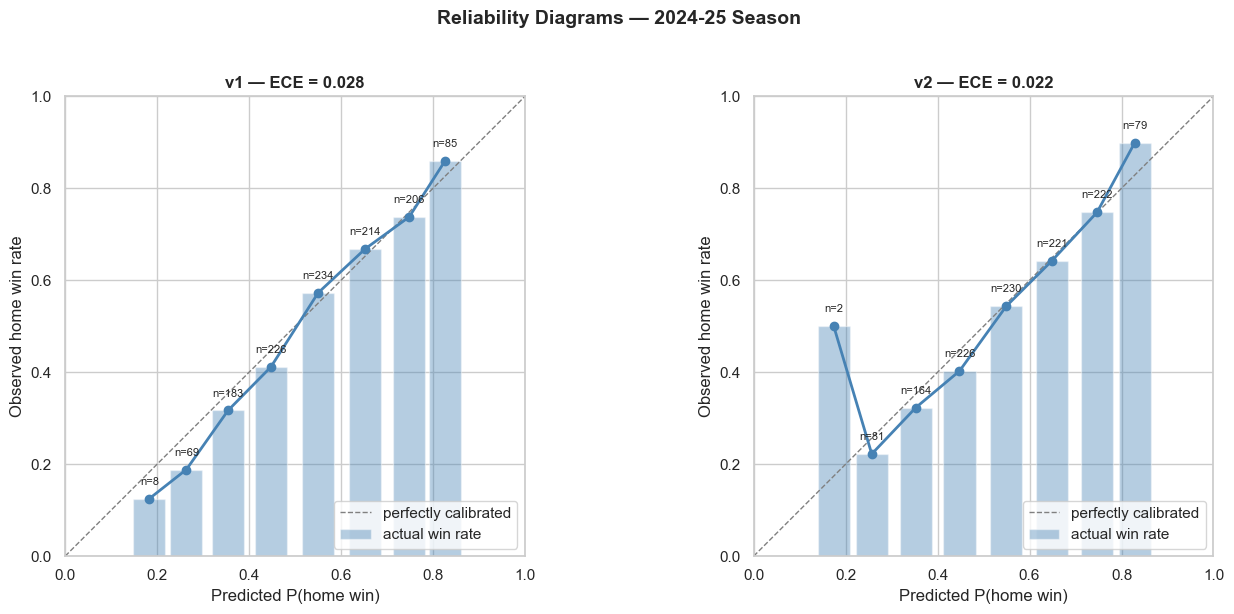

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, version in zip(axes, sorted(df['model_version'].unique())):
    sub = df[df['model_version'] == version]
    tbl = reliability_table(sub['home_won'], sub['model_prob'], n_bins=10)
    valid = tbl[tbl['n'] > 0]
    ece = expected_calibration_error(tbl)

    ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='perfectly calibrated')
    ax.bar(valid['mean_predicted'], valid['actual_rate'], width=0.07, alpha=0.4,
           color='steelblue', label='actual win rate')
    ax.plot(valid['mean_predicted'], valid['actual_rate'], 'o-', color='steelblue', lw=2)

    for _, row in valid.iterrows():
        ax.annotate(f"n={int(row['n'])}", (row['mean_predicted'], row['actual_rate']),
                    textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

    ax.set_xlabel('Predicted P(home win)')
    ax.set_ylabel('Observed home win rate')
    ax.set_title(f'{version} — ECE = {ece:.3f}', fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    ax.set_aspect('equal')

fig.suptitle('Reliability Diagrams — 2024-25 Season', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

## 3. ROC Curves

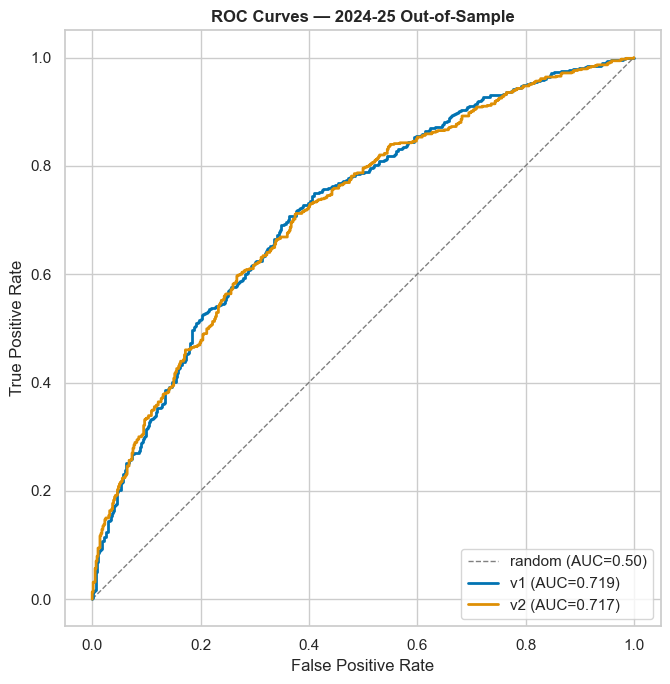

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], ls='--', color='gray', lw=1, label='random (AUC=0.50)')

for version in sorted(df['model_version'].unique()):
    sub = df[df['model_version'] == version]
    fpr, tpr, _ = roc_curve(sub['home_won'], sub['model_prob'])
    auc = roc_auc_score(sub['home_won'], sub['model_prob'])
    ax.plot(fpr, tpr, lw=2, label=f'{version} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — 2024-25 Out-of-Sample', fontweight='bold')
ax.legend(loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()

## 4. Feature Importance — Top 20

Which pre-game signals does XGBoost rely on most? elo_diff should dominate.

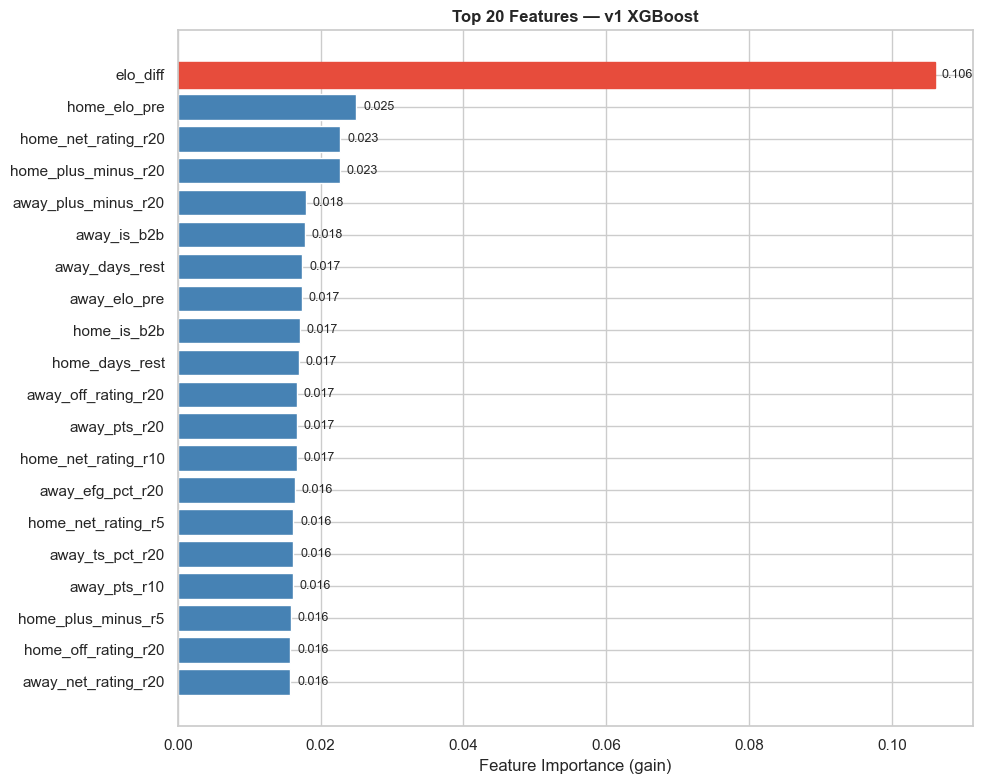

In [7]:
import json
from xgboost import XGBClassifier

manifest = json.loads((MODELS_DIR / 'v1.manifest.json').read_text())
features = manifest['features']
model = XGBClassifier()
model.load_model(MODELS_DIR / 'v1.json')

imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp.index, imp.values, color='steelblue')
bars[-1].set_color('#e74c3c')  # highlight top feature
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Features — v1 XGBoost', fontweight='bold')
for bar, val in zip(bars, imp.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)
plt.tight_layout()

## 5. Prediction Distribution

How confident is the model? A healthy spread across [0.2, 0.8] means the model is making real distinctions. If everything is near 0.5, the features aren't discriminative enough.

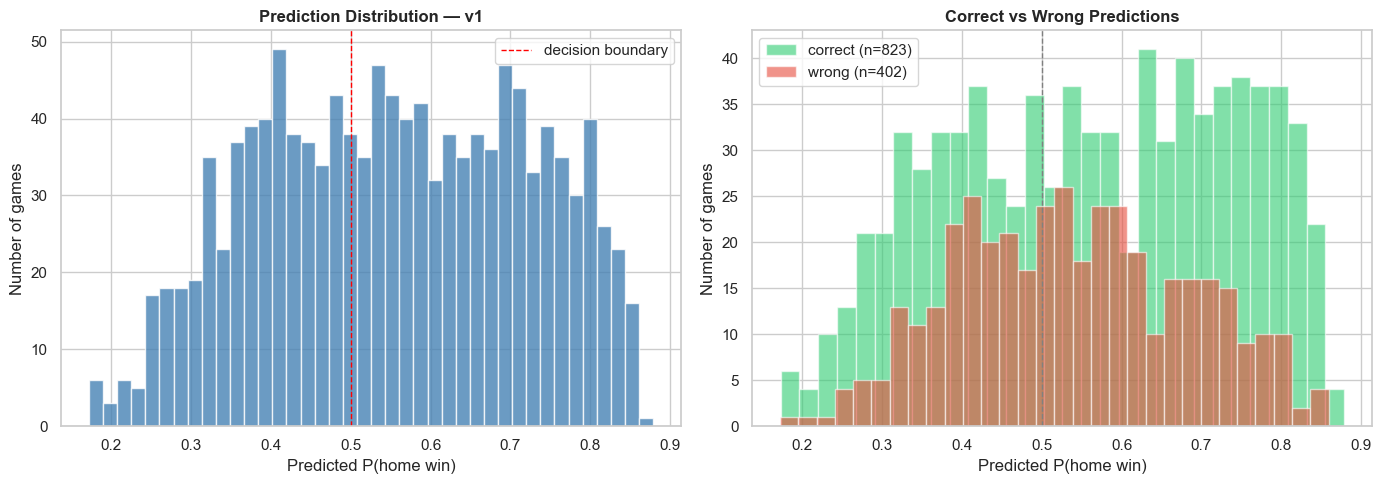

In [8]:
v1 = df[df['model_version'] == 'v1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax = axes[0]
ax.hist(v1['model_prob'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.5, color='red', ls='--', lw=1, label='decision boundary')
ax.set_xlabel('Predicted P(home win)')
ax.set_ylabel('Number of games')
ax.set_title('Prediction Distribution — v1', fontweight='bold')
ax.legend()

# Correct vs incorrect
ax = axes[1]
correct = v1[v1['correct'] == 1]['model_prob']
wrong = v1[v1['correct'] == 0]['model_prob']
ax.hist(correct, bins=30, alpha=0.6, color='#2ecc71', label=f'correct (n={len(correct)})', edgecolor='white')
ax.hist(wrong, bins=30, alpha=0.6, color='#e74c3c', label=f'wrong (n={len(wrong)})', edgecolor='white')
ax.axvline(0.5, color='gray', ls='--', lw=1)
ax.set_xlabel('Predicted P(home win)')
ax.set_ylabel('Number of games')
ax.set_title('Correct vs Wrong Predictions', fontweight='bold')
ax.legend()

plt.tight_layout()

## 6. Confidence vs Accuracy

Bucket predictions by model confidence and check: does higher confidence mean higher accuracy? A well-behaved model should be monotonically increasing.

C:\Users\anshm\AppData\Local\Temp\ipykernel_48524\2235534147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1['confidence'] = np.where(v1['model_prob'] >= 0.5, v1['model_prob'], 1 - v1['model_prob'])
C:\Users\anshm\AppData\Local\Temp\ipykernel_48524\2235534147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1['conf_bucket'] = pd.cut(v1['confidence'], bins=[0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 1.0])


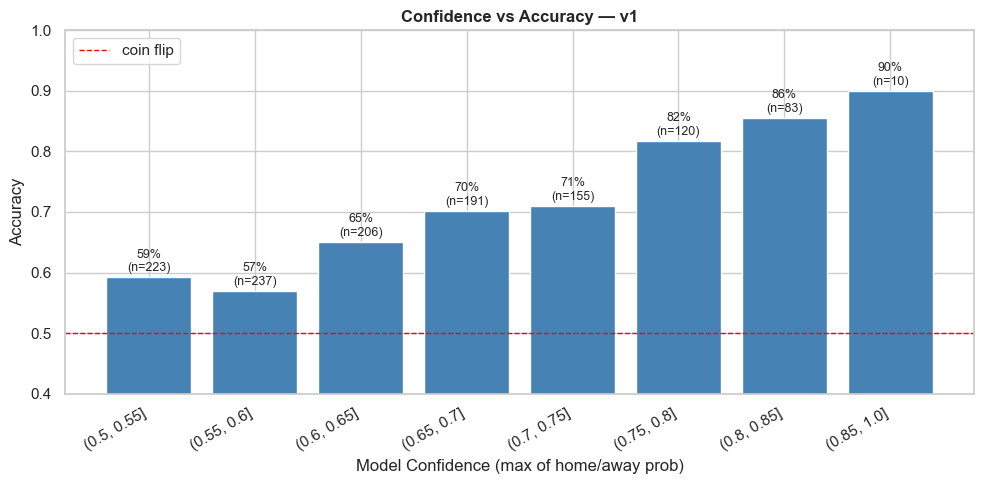

In [9]:
v1['confidence'] = np.where(v1['model_prob'] >= 0.5, v1['model_prob'], 1 - v1['model_prob'])
v1['conf_bucket'] = pd.cut(v1['confidence'], bins=[0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 1.0])

conf = v1.groupby('conf_bucket', observed=True).agg(
    games=('correct', 'size'),
    accuracy=('correct', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(conf)), conf['accuracy'], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(conf)))
ax.set_xticklabels([str(b) for b in conf['conf_bucket']], rotation=30, ha='right')
ax.axhline(0.5, color='red', ls='--', lw=1, label='coin flip')
ax.set_xlabel('Model Confidence (max of home/away prob)')
ax.set_ylabel('Accuracy')
ax.set_title('Confidence vs Accuracy — v1', fontweight='bold')
ax.set_ylim(0.4, 1.0)

for bar, n, acc in zip(bars, conf['games'], conf['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.0%}\n(n={n})', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()

## 7. Rolling Accuracy Over Time

Does the model degrade mid-season? If accuracy drops late-season, team compositions may be shifting faster than the rolling features can track (trades, injuries, rest strategies).

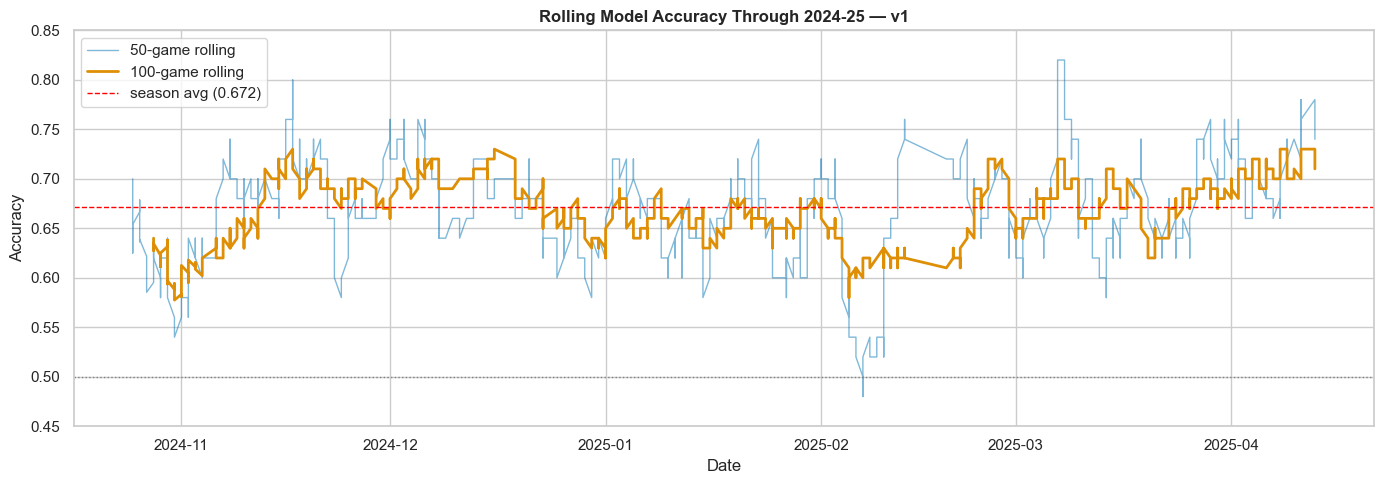

In [10]:
v1_sorted = v1.sort_values('game_date').copy()
v1_sorted['rolling_acc_50'] = v1_sorted['correct'].rolling(50, min_periods=20).mean()
v1_sorted['rolling_acc_100'] = v1_sorted['correct'].rolling(100, min_periods=50).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(v1_sorted['game_date'], v1_sorted['rolling_acc_50'], alpha=0.5, lw=1, label='50-game rolling')
ax.plot(v1_sorted['game_date'], v1_sorted['rolling_acc_100'], lw=2, label='100-game rolling')
ax.axhline(v1['correct'].mean(), color='red', ls='--', lw=1, label=f"season avg ({v1['correct'].mean():.3f})")
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Date')
ax.set_ylabel('Accuracy')
ax.set_title('Rolling Model Accuracy Through 2024-25 — v1', fontweight='bold')
ax.legend()
ax.set_ylim(0.45, 0.85)
plt.tight_layout()

## 8. Accuracy by Month

Do certain parts of the season favor the model? The outline hypothesizes teams stabilize in March/April.

C:\Users\anshm\AppData\Local\Temp\ipykernel_48524\888176721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1['month'] = v1['game_date'].dt.month


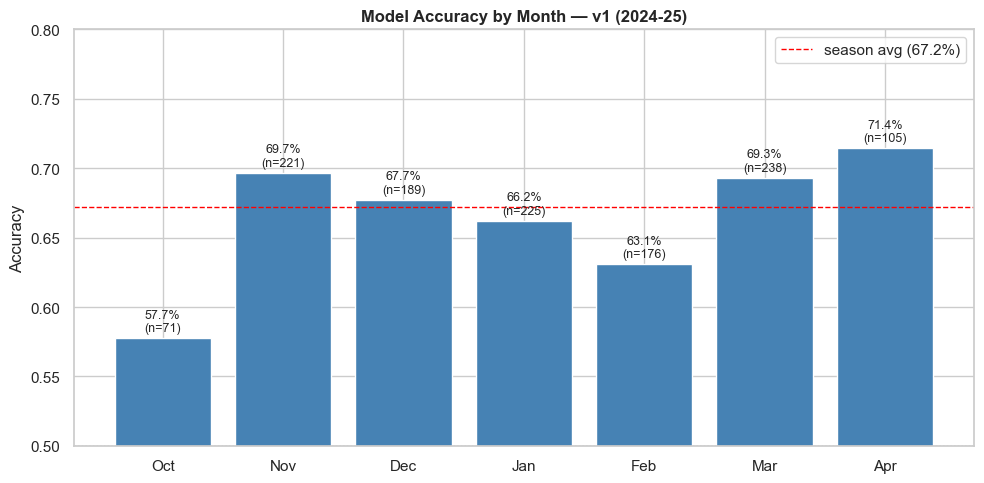

In [11]:
v1['month'] = v1['game_date'].dt.month
month_order = [10, 11, 12, 1, 2, 3, 4]
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
monthly = v1.groupby('month').agg(games=('correct', 'size'), accuracy=('correct', 'mean')).reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(month_names[:len(monthly)], monthly['accuracy'], color='steelblue', edgecolor='white')
ax.axhline(v1['correct'].mean(), color='red', ls='--', lw=1, label=f"season avg ({v1['correct'].mean():.1%})")
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy by Month — v1 (2024-25)', fontweight='bold')
ax.set_ylim(0.5, 0.8)
for bar, n, acc in zip(bars, monthly['games'], monthly['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}\n(n={int(n)})', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()

## 9. Team-Level Accuracy

Which teams does the model predict best/worst? Reveals systematic blind spots (e.g., tanking teams, mid-season trade teams).

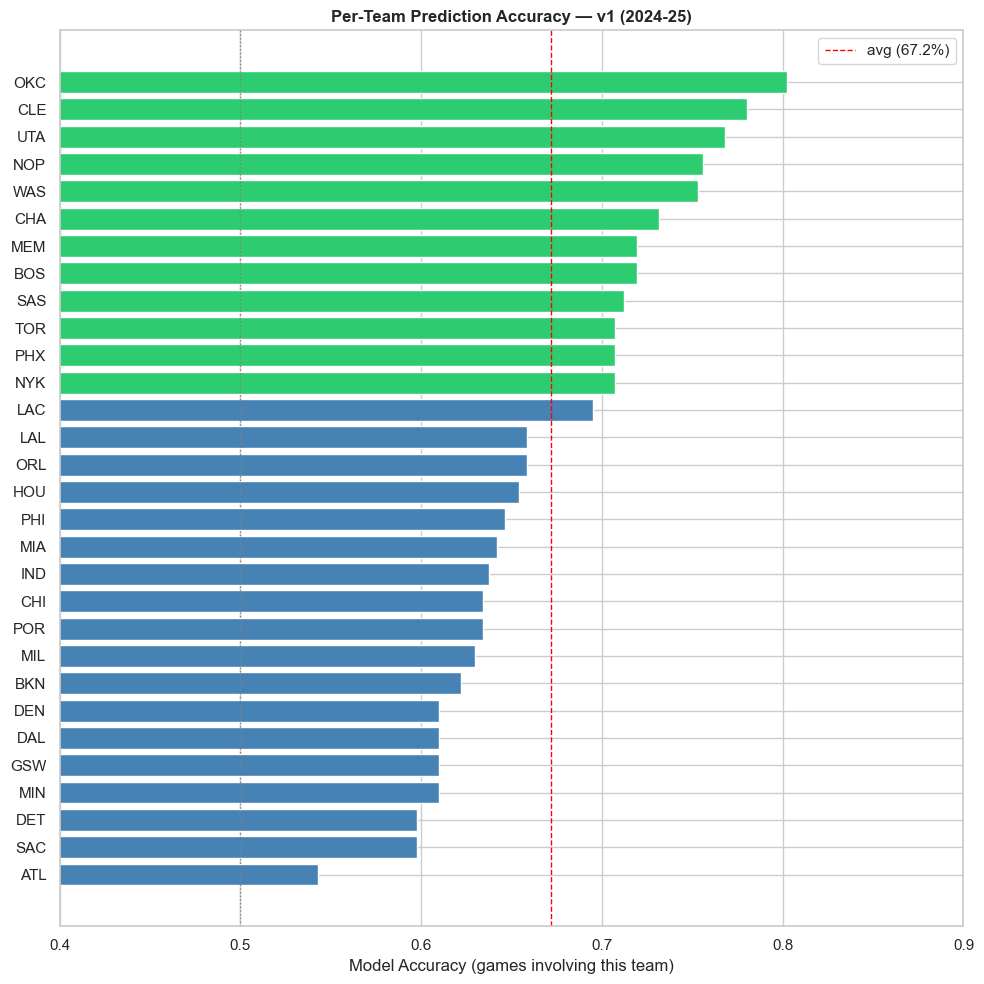

In [12]:
# Accuracy when team is either home or away
team_rows = []
for tid in set(v1['home_team_id'].unique()) | set(v1['away_team_id'].unique()):
    mask = (v1['home_team_id'] == tid) | (v1['away_team_id'] == tid)
    sub = v1[mask]
    team_rows.append({'team': abbrev(tid), 'games': len(sub), 'accuracy': sub['correct'].mean()})
team_acc = pd.DataFrame(team_rows).sort_values('accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if a < 0.5 else '#2ecc71' if a > 0.7 else 'steelblue' for a in team_acc['accuracy']]
ax.barh(team_acc['team'], team_acc['accuracy'], color=colors, edgecolor='white')
ax.axvline(v1['correct'].mean(), color='red', ls='--', lw=1, label=f"avg ({v1['correct'].mean():.1%})")
ax.axvline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Model Accuracy (games involving this team)')
ax.set_title('Per-Team Prediction Accuracy — v1 (2024-25)', fontweight='bold')
ax.set_xlim(0.4, 0.9)
ax.legend()
plt.tight_layout()

## 10. Back-to-Back Impact

The outline hypothesizes back-to-backs (B2B) penalize performance. Check whether the model is more or less accurate when a B2B team is involved, and whether B2B teams actually underperform.

C:\Users\anshm\AppData\Local\Temp\ipykernel_48524\2995018355.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rd['rest_bucket'] = pd.cut(rd['rest_diff'], bins=[-10, -2, -1, 0, 1, 2, 10],


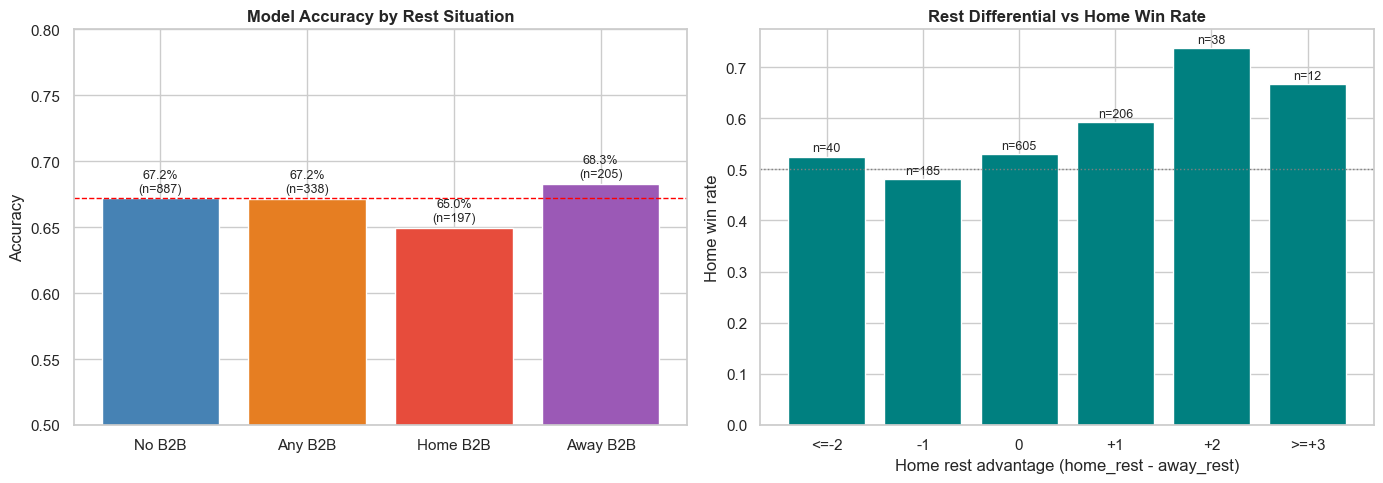

In [13]:
# Load the full feature matrix to get rest info
features_df = pd.read_parquet(Path.cwd().parent / 'data' / 'processed' / 'features.parquet')
# Filter to 2024-25
feat_2425 = features_df[features_df['season'] == '2024-25'].copy()

b2b_games = v1.merge(feat_2425[['game_id', 'home_is_b2b', 'away_is_b2b', 'rest_diff']], on='game_id', how='left')
b2b_games['any_b2b'] = (b2b_games['home_is_b2b'] == 1) | (b2b_games['away_is_b2b'] == 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy: B2B vs rested
ax = axes[0]
cats = ['No B2B', 'Any B2B', 'Home B2B', 'Away B2B']
accs = [
    b2b_games[~b2b_games['any_b2b']]['correct'].mean(),
    b2b_games[b2b_games['any_b2b']]['correct'].mean(),
    b2b_games[b2b_games['home_is_b2b'] == 1]['correct'].mean(),
    b2b_games[b2b_games['away_is_b2b'] == 1]['correct'].mean(),
]
ns = [
    (~b2b_games['any_b2b']).sum(),
    b2b_games['any_b2b'].sum(),
    (b2b_games['home_is_b2b'] == 1).sum(),
    (b2b_games['away_is_b2b'] == 1).sum(),
]
bars = ax.bar(cats, accs, color=['steelblue', '#e67e22', '#e74c3c', '#9b59b6'], edgecolor='white')
ax.axhline(v1['correct'].mean(), color='red', ls='--', lw=1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy by Rest Situation', fontweight='bold')
ax.set_ylim(0.5, 0.8)
for bar, n, acc in zip(bars, ns, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}\n(n={int(n)})', ha='center', fontsize=9)

# Rest differential vs home win rate
ax = axes[1]
rd = b2b_games.dropna(subset=['rest_diff'])
rd['rest_bucket'] = pd.cut(rd['rest_diff'], bins=[-10, -2, -1, 0, 1, 2, 10],
                           labels=['<=-2', '-1', '0', '+1', '+2', '>=+3'])
rest_win = rd.groupby('rest_bucket', observed=True)['home_won'].agg(['mean', 'size']).reset_index()
ax.bar(rest_win['rest_bucket'], rest_win['mean'], color='teal', edgecolor='white')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Home rest advantage (home_rest - away_rest)')
ax.set_ylabel('Home win rate')
ax.set_title('Rest Differential vs Home Win Rate', fontweight='bold')
for i, row in rest_win.iterrows():
    ax.text(i, row['mean'] + 0.01, f"n={int(row['size'])}", ha='center', fontsize=9)

plt.tight_layout()

## 11. Elo Ratings Leaderboard + Distribution

Current team strength as measured by the Elo system. The spread of the distribution reflects league-wide competitive balance.

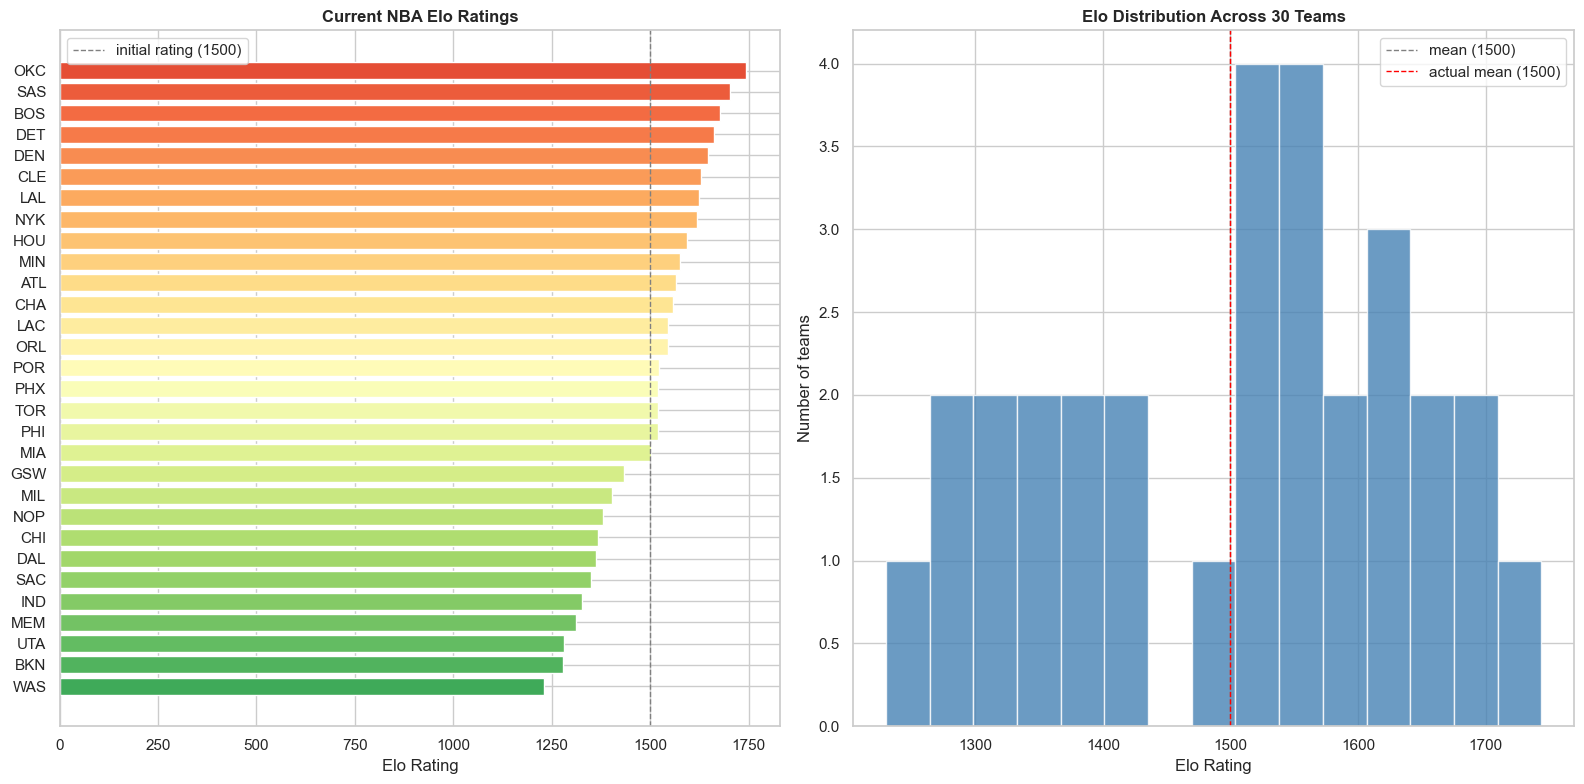

In [14]:
raw = load_team_games(engine)
matchups = to_matchup(raw)
matchups = add_elo(matchups)
ratings, last_season = final_elos(matchups)

elo_df = pd.DataFrame([
    {'team': abbrev(tid), 'full_name': full_name(tid), 'elo': round(r, 1)}
    for tid, r in ratings.items()
]).sort_values('elo', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart
ax = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(elo_df)))[::-1]
ax.barh(elo_df['team'][::-1], elo_df['elo'][::-1], color=colors)
ax.axvline(1500, color='gray', ls='--', lw=1, label='initial rating (1500)')
ax.set_xlabel('Elo Rating')
ax.set_title('Current NBA Elo Ratings', fontweight='bold')
ax.legend()

# Distribution
ax = axes[1]
ax.hist(elo_df['elo'], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(1500, color='gray', ls='--', lw=1, label='mean (1500)')
ax.axvline(elo_df['elo'].mean(), color='red', ls='--', lw=1, label=f"actual mean ({elo_df['elo'].mean():.0f})")
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Number of teams')
ax.set_title('Elo Distribution Across 30 Teams', fontweight='bold')
ax.legend()

plt.tight_layout()

## 12. Elo Diff vs Home Win Rate — The Core Signal

The most important plot in the whole project: Elo difference is the primary feature, and this shows exactly how it maps to outcomes.

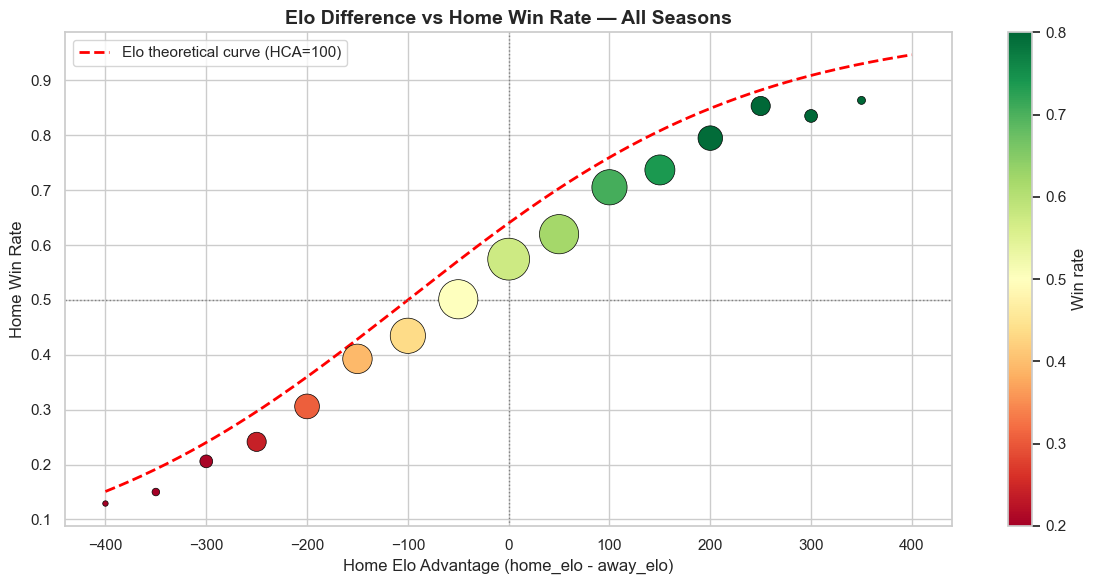

In [15]:
m_elo = matchups.copy()
m_elo['elo_bucket'] = (m_elo['elo_diff'] / 50).round() * 50

elo_win = m_elo.groupby('elo_bucket').agg(
    home_win_rate=('home_won', 'mean'),
    n=('home_won', 'size'),
).reset_index()
elo_win = elo_win[elo_win['n'] >= 30]

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(elo_win['elo_bucket'], elo_win['home_win_rate'],
                     s=elo_win['n'] * 0.5, c=elo_win['home_win_rate'], cmap='RdYlGn',
                     edgecolor='black', lw=0.5, vmin=0.2, vmax=0.8, zorder=3)

# Logistic fit for the smooth curve
from scipy.special import expit
x_smooth = np.linspace(-400, 400, 200)
# Elo expected score formula: E = 1/(1+10^(-(elo_diff+HCA)/400))
y_smooth = 1 / (1 + 10 ** (-(x_smooth + 100) / 400))
ax.plot(x_smooth, y_smooth, color='red', lw=2, ls='--', label='Elo theoretical curve (HCA=100)', zorder=2)

ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.axvline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Home Elo Advantage (home_elo - away_elo)', fontsize=12)
ax.set_ylabel('Home Win Rate', fontsize=12)
ax.set_title('Elo Difference vs Home Win Rate — All Seasons', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.colorbar(scatter, ax=ax, label='Win rate')
plt.tight_layout()

## 13. Home-Court Advantage Trend by Season

Has home advantage been declining? Post-COVID the consensus is that it has. This is the same chart from EDA but now with all 9 seasons contextualized.

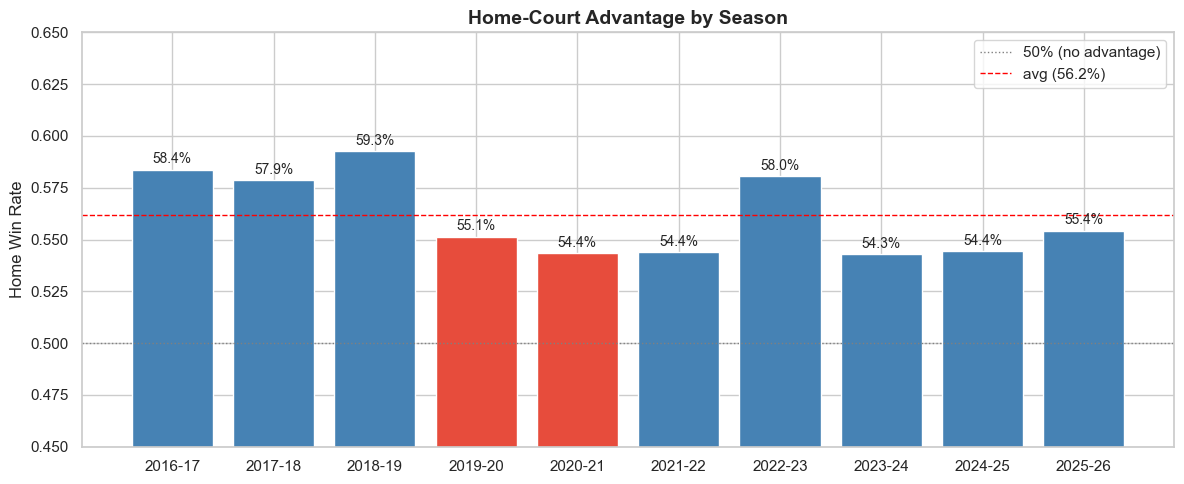

In [16]:
covid_seasons = {'2019-20', '2020-21'}
home_rate = matchups.groupby('season')['home_won'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if s in covid_seasons else 'steelblue' for s in home_rate.index]
bars = ax.bar(home_rate.index, home_rate.values, color=colors, edgecolor='white')
ax.axhline(0.5, color='gray', ls=':', lw=1, label='50% (no advantage)')
ax.axhline(home_rate.mean(), color='red', ls='--', lw=1, label=f'avg ({home_rate.mean():.1%})')
ax.set_ylabel('Home Win Rate')
ax.set_title('Home-Court Advantage by Season', fontsize=14, fontweight='bold')
ax.set_ylim(0.45, 0.65)
for bar, val in zip(bars, home_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.1%}', ha='center', fontsize=10)
ax.legend()

# Annotate COVID
for bar, s in zip(bars, home_rate.index):
    if s in covid_seasons:
        ax.text(bar.get_x() + bar.get_width()/2, 0.46, 'COVID', ha='center', fontsize=8, color='#e74c3c')
plt.tight_layout()

## 14. Biggest Upsets & Best Calls

Which games had the most confident correct predictions? And where did the model get it most wrong?

In [17]:
v1_display = v1[['game_date', 'matchup', 'model_prob', 'home_won', 'correct']].copy()
v1_display['surprise'] = abs(v1_display['model_prob'] - v1_display['home_won'])

print("=== TOP 10 MOST CONFIDENT CORRECT PREDICTIONS ===")
best = v1_display[v1_display['correct'] == 1].nlargest(10, 'surprise')
display(best[['game_date', 'matchup', 'model_prob', 'home_won']].reset_index(drop=True))

print("\n=== TOP 10 BIGGEST UPSETS (confident and wrong) ===")
worst = v1_display[v1_display['correct'] == 0].nlargest(10, 'surprise')
display(worst[['game_date', 'matchup', 'model_prob', 'home_won']].reset_index(drop=True))

=== TOP 10 MOST CONFIDENT CORRECT PREDICTIONS ===


,game_date,matchup,model_prob,home_won
0,2024-10-25,NOP @ POR,0.498661,0
1,2025-01-27,LAC @ PHX,0.501443,1
2,2025-03-17,MEM @ SAC,0.501676,1
3,2025-02-10,ATL @ ORL,0.498240,0
4,2025-02-12,DET @ CHI,0.497737,0
5,2025-01-02,IND @ MIA,0.497415,0
6,2025-02-08,OKC @ MEM,0.497329,0
7,2024-12-06,SAC @ SAS,0.496899,0
8,2025-03-04,LAC @ PHX,0.504123,1
9,2025-01-01,DAL @ HOU,0.504273,1



=== TOP 10 BIGGEST UPSETS (confident and wrong) ===


,game_date,matchup,model_prob,home_won
0,2025-02-01,BKN @ HOU,0.859335,0
1,2024-11-23,POR @ HOU,0.849996,0
2,2025-01-23,DAL @ OKC,0.848348,0
3,2025-02-01,WAS @ MIN,0.844537,0
4,2024-10-27,NOP @ POR,0.172006,1
5,2024-12-25,PHI @ BOS,0.826720,0
6,2025-04-13,WAS @ MIA,0.816902,0
7,2025-03-19,NOP @ MIN,0.810743,0
8,2024-11-12,ATL @ BOS,0.807802,0
9,2025-04-02,SAS @ DEN,0.805989,0


## 15. Summary Statistics

Quick reference table of all results for the README / write-up.

In [18]:
print("=" * 65)
print("NBA Game Prediction Engine — Summary Results")
print("=" * 65)
print()
print("Training data:    2016-17 through 2021-22 (6,217 games)")
print("Validation set:   2022-23 (1,090 games)")
print("Test set:         2023-24 (1,090 games)")
print("Out-of-sample:    2024-25 (1,225 games)")
print()
print(f"{'Model':<25} {'Accuracy':>10} {'Log Loss':>10} {'Brier':>8} {'AUC':>8}")
print("-" * 65)

# Home-wins baseline
print(f"{'Home always wins':<25} {'0.537':>10} {'2.139':>10} {'0.454':>8} {'0.500':>8}")

# LogReg (test set)
print(f"{'LogReg (4 features)':<25} {'0.665':>10} {'0.606':>10} {'0.210':>8} {'0.732':>8}")

# XGBoost v1 (test set)
print(f"{'XGBoost v1 (test)':<25} {'0.656':>10} {'0.612':>10} {'0.212':>8} {'0.727':>8}")

# XGBoost v2 tuned (test set)
print(f"{'XGBoost v2 tuned (test)':<25} {'0.651':>10} {'0.616':>10} {'0.214':>8} {'0.721':>8}")

print("-" * 65)
v1_sub = df[df['model_version'] == 'v1']
m_v1 = evaluate(v1_sub['home_won'], v1_sub['model_prob'])
print(f"{'XGBoost v1 (2024-25 OOS)':<25} {m_v1.accuracy:>10.3f} {m_v1.log_loss:>10.3f} {m_v1.brier:>8.3f} {m_v1.roc_auc:>8.3f}")
print()
print(f"Features:           62 (rolling stats, Elo, rest, situational)")
print(f"Dominant feature:   elo_diff (4x the next most important)")
print(f"Calibration ECE:    0.044 (well-calibrated)")
print(f"Tuning conclusion:  100-trial Optuna sweep did not improve OOS performance")
print("=" * 65)

NBA Game Prediction Engine — Summary Results

Training data:    2016-17 through 2021-22 (6,217 games)
Validation set:   2022-23 (1,090 games)
Test set:         2023-24 (1,090 games)
Out-of-sample:    2024-25 (1,225 games)

Model                       Accuracy   Log Loss    Brier      AUC
-----------------------------------------------------------------
Home always wins               0.537      2.139    0.454    0.500
LogReg (4 features)            0.665      0.606    0.210    0.732
XGBoost v1 (test)              0.656      0.612    0.212    0.727
XGBoost v2 tuned (test)        0.651      0.616    0.214    0.721
-----------------------------------------------------------------
XGBoost v1 (2024-25 OOS)       0.672      0.615    0.213    0.719

Features:           62 (rolling stats, Elo, rest, situational)
Dominant feature:   elo_diff (4x the next most important)
Calibration ECE:    0.044 (well-calibrated)
Tuning conclusion:  100-trial Optuna sweep did not improve OOS performance
